# Boltzmann Machines

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
from torch.autograd import Variable

## Importing the dataset

In [2]:
movies = pd.read_csv('dataset/ml-1m/movies.dat', sep = '::', header = None, engine = 'python', encoding = 'latin-1')
users = pd.read_csv('dataset/ml-1m/users.dat', sep = '::', header = None, engine = 'python', encoding = 'latin-1')
ratings = pd.read_csv('dataset/ml-1m/ratings.dat', sep = '::', header = None, engine = 'python', encoding = 'latin-1')

## Preparing the training set and the test set

In [3]:
training_set = pd.read_csv('dataset/ml-100k/u1.base', delimiter = '\t')
training_set = np.array(training_set, dtype = 'int')
test_set = pd.read_csv('dataset/ml-100k/u1.test', delimiter = '\t')
test_set = np.array(test_set, dtype = 'int')

## Getting the number of users and movies

In [4]:
nb_users = int(max(max(training_set[:,0]), max(test_set[:,0])))
nb_movies = int(max(max(training_set[:,1]), max(test_set[:,1])))

## Converting the data into an array with users in lines and movies in columns

In [5]:
def convert(data):
    new_data = []
    for id_users in range(1, nb_users + 1):
        id_movies = data[:,1][data[:,0] == id_users]
        id_ratings = data[:,2][data[:,0] == id_users]
        ratings = np.zeros(nb_movies)
        ratings[id_movies - 1] = id_ratings
        new_data.append(list(ratings))
    return new_data
training_set = convert(training_set)
test_set = convert(test_set)

## Converting the data into Torch tensors

In [6]:
training_set = torch.FloatTensor(training_set)
test_set = torch.FloatTensor(test_set)

## Converting the ratings into binary ratings 1 (Liked) or 0 (Not Liked)

In [7]:
training_set[training_set == 0] = -1
training_set[training_set == 1] = 0
training_set[training_set == 2] = 0
training_set[training_set >= 3] = 1
test_set[test_set == 0] = -1
test_set[test_set == 1] = 0
test_set[test_set == 2] = 0
test_set[test_set >= 3] = 1

## Creating the architecture of the Neural Network

In [8]:
class RBM():
    def __init__(self, nv, nh):
        self.W = torch.randn(nh, nv)
        self.a = torch.randn(1, nh)
        self.b = torch.randn(1, nv)
    def sample_h(self, x):
        wx = torch.mm(x, self.W.t())
        activation = wx + self.a.expand_as(wx)
        p_h_given_v = torch.sigmoid(activation)
        return p_h_given_v, torch.bernoulli(p_h_given_v)
    def sample_v(self, y):
        wy = torch.mm(y, self.W)
        activation = wy + self.b.expand_as(wy)
        p_v_given_h = torch.sigmoid(activation)
        return p_v_given_h, torch.bernoulli(p_v_given_h)
    def train(self, v0, vk, ph0, phk):
        self.W += torch.mm(v0.t(), ph0).t() - torch.mm(vk.t(), phk).t()
        self.b += torch.sum((v0 - vk), 0)
        self.a += torch.sum((ph0 - phk), 0)
nv = len(training_set[0])
nh = 100
batch_size = 100
rbm = RBM(nv, nh)

## Training the RBM

In [19]:
nb_epoch = 10
for epoch in range(1, nb_epoch + 1):
    train_loss = 0
    s = 0.
    for id_user in range(0, nb_users - batch_size, batch_size):
        vk = training_set[id_user:id_user+batch_size]
        v0 = training_set[id_user:id_user+batch_size]
        ph0,_ = rbm.sample_h(v0)
        for k in range(10):
            _,hk = rbm.sample_h(vk)
            _,vk = rbm.sample_v(hk)
            vk[v0<0] = v0[v0<0]
        phk,_ = rbm.sample_h(vk)
        rbm.train(v0, vk, ph0, phk)
        train_loss += torch.mean(torch.abs(v0[v0>=0] - vk[v0>=0]))
        s += 1.
    print('epoch: '+str(epoch)+' loss: '+str(train_loss/s))

epoch: 1 loss: tensor(0.2500)
epoch: 2 loss: tensor(0.2458)
epoch: 3 loss: tensor(0.2453)
epoch: 4 loss: tensor(0.2446)
epoch: 5 loss: tensor(0.2454)
epoch: 6 loss: tensor(0.2473)
epoch: 7 loss: tensor(0.2447)
epoch: 8 loss: tensor(0.2453)
epoch: 9 loss: tensor(0.2450)
epoch: 10 loss: tensor(0.2469)


## Testing the RBM

In [20]:
test_loss = 0
s = 0.
for id_user in range(nb_users):
    v = training_set[id_user:id_user+1]
    vt = test_set[id_user:id_user+1]
    if len(vt[vt>=0]) > 0:
        _,h = rbm.sample_h(v)
        _,v = rbm.sample_v(h)
        test_loss += torch.mean(torch.abs(vt[vt>=0] - v[vt>=0]))
        s += 1.
print('test loss: '+str(test_loss/s))

test loss: tensor(0.2522)


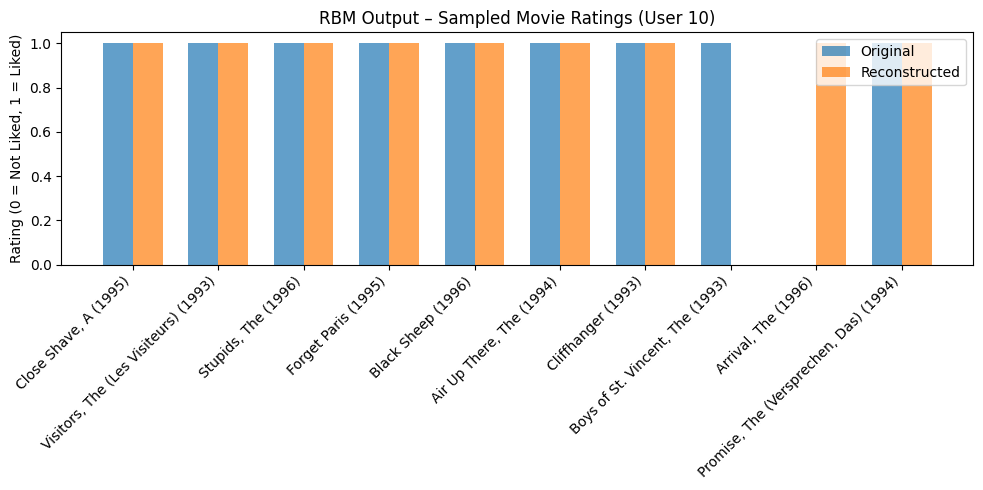

In [17]:
import matplotlib.pyplot as plt
import random

# Choose a user
user_id = 10
v = training_set[user_id:user_id+1]
_, h = rbm.sample_h(v)
_, v_reconstructed = rbm.sample_v(h)
# Column 0 = MovieID, Column 1 = Title
movie_titles = {}
with open('dataset/ml-1m/movies.dat', encoding='latin-1') as f:
    for line in f:
        parts = line.strip().split("::")
        movie_id = int(parts[0])
        title = parts[1]
        movie_titles[movie_id] = title


v_original = v[0].detach().numpy()
v_recon = v_reconstructed[0].detach().numpy()

# Only keep movies that were actually rated (original ≠ -1)
rated_indices = [i for i, val in enumerate(v_original) if val != -1]

# Randomly select 10 rated movies to visualise
sample_indices = random.sample(rated_indices, 10)

# Prepare data for plotting
movie_labels = [movie_titles[i + 1] for i in sample_indices]  # +1 for 0-based index
original_ratings = [v_original[i] for i in sample_indices]
reconstructed_ratings = [v_recon[i] for i in sample_indices]

# Plotting
x = range(len(sample_indices))
bar_width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x, original_ratings, width=bar_width, label='Original', alpha=0.7)
plt.bar([i + bar_width for i in x], reconstructed_ratings, width=bar_width, label='Reconstructed', alpha=0.7)
plt.xticks([i + bar_width / 2 for i in x], movie_labels, rotation=45, ha='right')
plt.ylabel("Rating (0 = Not Liked, 1 = Liked)")
plt.title(f"RBM Output – Sampled Movie Ratings (User {user_id})")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Generate predictions
user_id = 10
v = training_set[user_id:user_id+1]
_, h = rbm.sample_h(v)
_, v_reconstructed = rbm.sample_v(h)

# Get top N recommendations (unrated movies with highest predicted "like")
v_user = v[0]
v_pred = v_reconstructed[0]
unrated = (v_user == -1)
recommended_scores = v_pred[unrated]
recommended_indices = torch.topk(recommended_scores, k=10).indices

# Display top recommended movie indices
print("Top 10 recommended movie indices for user", user_id, ":", recommended_indices.tolist())


Top 10 recommended movie indices for user 10 : [8, 9, 4, 7, 0, 3, 1, 11, 10, 6]
